# Option B — ERA5 + Peak GCVI (Sentinel-2, 2017–2023)

**Design**
| Split | Years | Rows (~22 districts) |
|---|---|---|
| Train | 2017–2022 | ~132 |
| Test | 2023 | ~22 |

**Covariates:** ERA5 monthly (Jun–Sep) + district-level peak GCVI from S2  
**Target:** Rice yield (kg/ha)  
**Models:** Ridge, Random Forest

In [1]:
import pandas as pd
import numpy as np
import glob, re
import rasterio
from rasterstats import zonal_stats
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## 1. Extract district-level peak GCVI from TIF files

For each year's TIF, run zonal stats over the Punjab district polygons to get mean peak GCVI per district.

In [2]:
districts = gpd.read_file('data/punjab_districts_GAUL/Punjab_Districts_GAUL.shp').to_crs('EPSG:4326')
districts['gaul2_name'] = districts['gaul2_name'].str.strip().str.title()

tif_files = sorted(glob.glob('data/assets/peak_gcvi_kharif_*_punjab.tif'))
print(f"Found {len(tif_files)} GCVI TIF files:")
for f in tif_files:
    print(f"  {f.split('/')[-1]}")

Found 8 GCVI TIF files:
  peak_gcvi_kharif_2017_punjab.tif
  peak_gcvi_kharif_2018_punjab.tif
  peak_gcvi_kharif_2019_punjab.tif
  peak_gcvi_kharif_2020_punjab.tif
  peak_gcvi_kharif_2021_punjab.tif
  peak_gcvi_kharif_2022_punjab.tif
  peak_gcvi_kharif_2023_punjab.tif
  peak_gcvi_kharif_2024_punjab.tif


In [3]:
records = []
for tif in tif_files:
    year = int(re.search(r'_(\d{4})_punjab', tif).group(1))

    # Clean the raster: replace inf/-inf with NaN before zonal stats
    with rasterio.open(tif) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata
        profile = src.profile

    data[np.isinf(data)] = np.nan
    if nodata is not None:
        data[data == nodata] = np.nan

    # Write cleaned array to a temporary in-memory view via a temp file
    import tempfile, os
    with tempfile.NamedTemporaryFile(suffix='.tif', delete=False) as tmp:
        tmp_path = tmp.name
    profile.update(dtype=rasterio.float32, nodata=np.nan)
    with rasterio.open(tmp_path, 'w', **profile) as dst:
        dst.write(data.astype(np.float32), 1)

    stats = zonal_stats(districts, tmp_path, stats=['mean', 'median'], nodata=np.nan)
    os.unlink(tmp_path)

    for i, row in districts.iterrows():
        records.append({
            'district': row['gaul2_name'],
            'year': year,
            'gcvi_mean':   stats[i]['mean'],
            'gcvi_median': stats[i]['median'],
        })

gcvi_df = pd.DataFrame(records).dropna()
print(f"GCVI table shape: {gcvi_df.shape}")
print(f"Years: {sorted(gcvi_df['year'].unique())}")
gcvi_df.head(8)

GCVI table shape: (176, 4)
Years: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


,district,year,gcvi_mean,gcvi_median
0,Amritsar,2017,4.087792,4.002865
1,Barnala,2017,5.560144,5.684789
2,Bathinda,2017,4.790057,4.850103
3,Faridkot,2017,4.791066,4.771791
4,Fatehgarh Sahib,2017,5.230497,5.054920
5,Fazilka,2017,4.409919,4.390448
6,Firozpur,2017,5.180948,5.231911
7,Gurdaspur,2017,2.541883,2.233622


## 2. Load ERA5 features (Jun–Sep, same as Option A)

In [4]:
era5 = pd.read_csv('data/era5_kharif_features_punjab.csv')

MONTH_NAMES = {6:'jun', 7:'jul', 8:'aug', 9:'sep'}
ERA5_VARS   = ['tp_mm', 'pev_mm', 't2m_c', 'swvl1', 'lai_lv']

era5_filtered = era5[era5['month'].isin(MONTH_NAMES)].copy()
era5_filtered['month_name'] = era5_filtered['month'].map(MONTH_NAMES)

era5_wide = era5_filtered.pivot_table(
    index=['district', 'year'],
    columns='month_name',
    values=ERA5_VARS
)
era5_wide.columns = [f'{var}_{mon}' for var, mon in era5_wide.columns]
era5_wide = era5_wide.reset_index()

print(f"ERA5 wide shape: {era5_wide.shape}")

ERA5 wide shape: (264, 22)


## 3. Load yield data

In [5]:
def load_des_csv(path):
    df = pd.read_csv(path, encoding='utf-8-sig')
    rice = df[(df['State'] == 'Punjab') & (df['Season'] == 'Kharif') & (df['Crop'] == 'Rice')].copy()
    yield_cols = [c for c in df.columns if c.startswith('Yield-')]
    rows = []
    for col in yield_cols:
        year = int(re.search(r'Yield-(\d{4})', col).group(1))
        sub = rice[['District', col]].copy()
        sub.columns = ['district', 'rice_yield_kg_ha']
        sub['rice_yield_kg_ha'] = pd.to_numeric(sub['rice_yield_kg_ha'], errors='coerce')
        sub['year'] = year
        rows.append(sub)
    return pd.concat(rows, ignore_index=True)

des_files = sorted(glob.glob('data/DES-District-Data-For-*-to-*.csv'))
yield_df = pd.concat([load_des_csv(f) for f in des_files], ignore_index=True)
yield_df['district'] = yield_df['district'].str.strip().str.title()
yield_df['district'] = yield_df['district'].replace({'Ferozepur': 'Firozpur', 'S.A.S Nagar': 'Sas Nagar (Sahibzada Ajit Singh Nagar)'})
yield_df = yield_df.dropna(subset=['rice_yield_kg_ha'])
print(f"Yield data: {yield_df.shape}, years: {sorted(yield_df['year'].unique())}")

Yield data: (268, 3), years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


## 4. Join ERA5 + GCVI + yield & restrict to S2 years (2017+)

In [6]:
panel = (
    era5_wide
    .merge(gcvi_df[['district', 'year', 'gcvi_mean']], on=['district', 'year'], how='inner')
    .merge(yield_df, on=['district', 'year'], how='inner')
    .dropna()
)

# Restrict to S2 era
panel = panel[panel['year'] >= 2017]

FEATURE_COLS = [c for c in panel.columns if c not in ('district', 'year', 'rice_yield_kg_ha')]

print(f"Panel shape: {panel.shape}")
print(f"Years: {sorted(panel['year'].unique())}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Panel shape: (176, 24)
Years: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Features (21): ['lai_lv_aug', 'lai_lv_jul', 'lai_lv_jun', 'lai_lv_sep', 'pev_mm_aug', 'pev_mm_jul', 'pev_mm_jun', 'pev_mm_sep', 'swvl1_aug', 'swvl1_jul', 'swvl1_jun', 'swvl1_sep', 't2m_c_aug', 't2m_c_jul', 't2m_c_jun', 't2m_c_sep', 'tp_mm_aug', 'tp_mm_jul', 'tp_mm_jun', 'tp_mm_sep', 'gcvi_mean']


## 5. Train / test split & fit models

In [7]:
TEST_YEAR = 2023

train = panel[panel['year'] < TEST_YEAR]
test  = panel[panel['year'] == TEST_YEAR]

X_train, y_train = train[FEATURE_COLS].values, train['rice_yield_kg_ha'].values
X_test,  y_test  = test[FEATURE_COLS].values,  test['rice_yield_kg_ha'].values

print(f"Train: {X_train.shape[0]} rows ({train['year'].min()}–{train['year'].max()})")
print(f"Test:  {X_test.shape[0]} rows (year={TEST_YEAR})")

def eval_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae  = np.mean(np.abs(y_true - y_pred))
    print(f"{label:15s}  RMSE={rmse:7.1f} kg/ha   MAE={mae:7.1f} kg/ha   R²={r2:.3f}")
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

# Ridge
ridge_pipe = Pipeline([('scaler', StandardScaler()), ('model', RidgeCV(alphas=np.logspace(-2, 4, 50), cv=None))])
ridge_pipe.fit(X_train, y_train)
print(f"\nBest alpha (LOO-CV): {ridge_pipe.named_steps['model'].alpha_:.3f}")
print("\n--- Ridge ---")
ridge_train_metrics = eval_metrics(y_train, ridge_pipe.predict(X_train), 'Train')
ridge_test_metrics  = eval_metrics(y_test,  ridge_pipe.predict(X_test),  f'Test ({TEST_YEAR})')

# Random Forest
rf = RandomForestRegressor(n_estimators=500, max_features='sqrt', random_state=42)
rf.fit(X_train, y_train)
print("\n--- Random Forest ---")
rf_train_metrics = eval_metrics(y_train, rf.predict(X_train), 'Train')
rf_test_metrics  = eval_metrics(y_test,  rf.predict(X_test),  f'Test ({TEST_YEAR})')

Train: 132 rows (2017–2022)
Test:  22 rows (year=2023)

Best alpha (LOO-CV): 0.010

--- Ridge ---
Train            RMSE=  294.3 kg/ha   MAE=  224.9 kg/ha   R²=0.731
Test (2023)      RMSE=  353.3 kg/ha   MAE=  294.8 kg/ha   R²=0.581

--- Random Forest ---
Train            RMSE=  128.8 kg/ha   MAE=   98.8 kg/ha   R²=0.948
Test (2023)      RMSE=  413.5 kg/ha   MAE=  361.2 kg/ha   R²=0.427


## 6. Evaluate: predicted vs actual

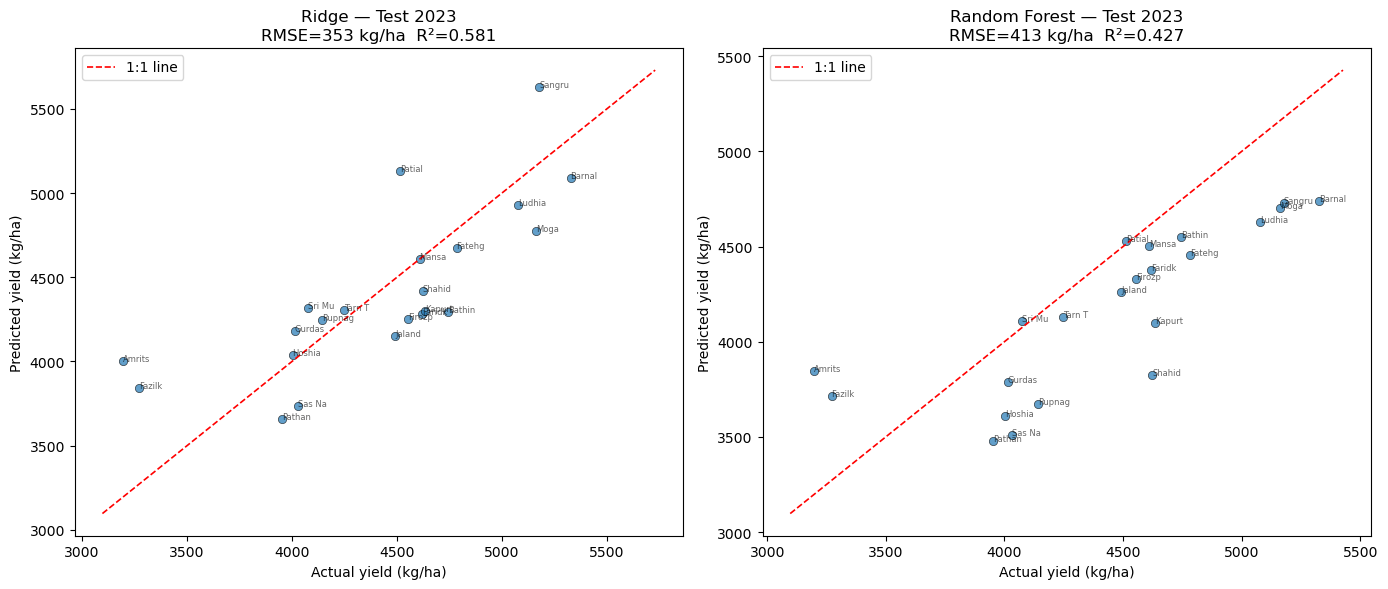

In [8]:
results = test[['district', 'year', 'rice_yield_kg_ha']].copy()
results['ridge_pred'] = ridge_pipe.predict(X_test)
results['rf_pred']    = rf.predict(X_test)
results['ridge_err']  = results['ridge_pred'] - results['rice_yield_kg_ha']
results['rf_err']     = results['rf_pred']    - results['rice_yield_kg_ha']
results = results.sort_values('rice_yield_kg_ha')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, pred_col, title in zip(axes, ['ridge_pred', 'rf_pred'], ['Ridge', 'Random Forest']):
    ax.scatter(results['rice_yield_kg_ha'], results[pred_col], alpha=0.7, edgecolors='k', linewidths=0.5)
    lims = [results[['rice_yield_kg_ha', pred_col]].min().min() - 100,
            results[['rice_yield_kg_ha', pred_col]].max().max() + 100]
    ax.plot(lims, lims, 'r--', linewidth=1.2, label='1:1 line')
    for _, row in results.iterrows():
        ax.annotate(row['district'][:6], (row['rice_yield_kg_ha'], row[pred_col]), fontsize=6, alpha=0.6)
    rmse = np.sqrt(mean_squared_error(results['rice_yield_kg_ha'], results[pred_col]))
    r2   = r2_score(results['rice_yield_kg_ha'], results[pred_col])
    ax.set_title(f'{title} — Test {TEST_YEAR}\nRMSE={rmse:.0f} kg/ha  R²={r2:.3f}')
    ax.set_xlabel('Actual yield (kg/ha)')
    ax.set_ylabel('Predicted yield (kg/ha)')
    ax.legend()
plt.tight_layout()
plt.show()

## 7. GCVI feature importance & comparison with Option A

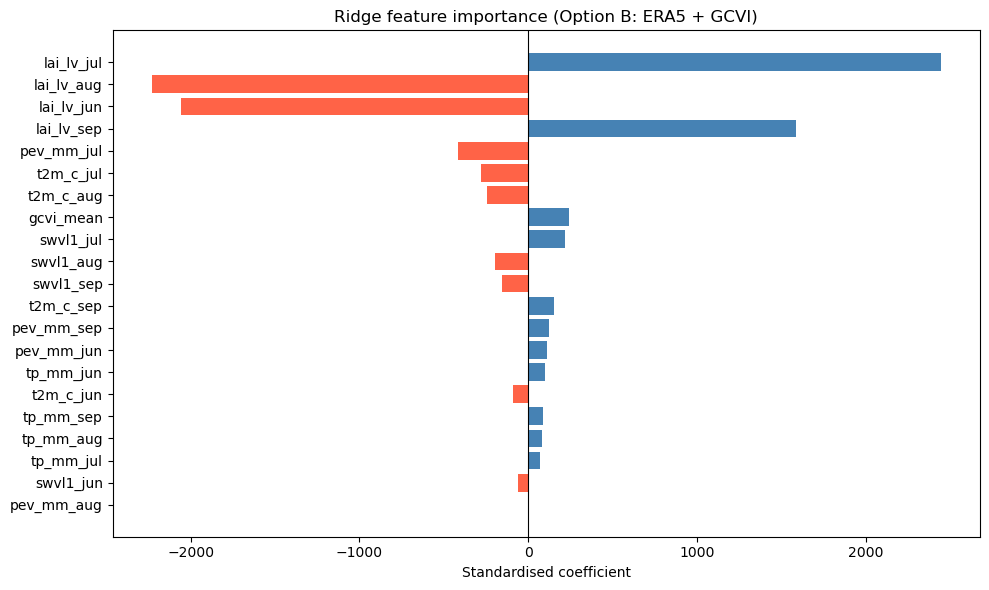


=== Option A vs Option B (Test 2023, Ridge) ===
Option A — ERA5 only (2013–2022 train):  R²=0.396  RMSE=424 kg/ha
Option B — ERA5+GCVI (2017–2022 train):  R²=0.581  RMSE=353 kg/ha


In [9]:
# Ridge coefficients — how much weight does GCVI get vs ERA5 variables?
coef_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': ridge_pipe.named_steps['model'].coef_
}).sort_values('coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardised coefficient')
ax.set_title('Ridge feature importance (Option B: ERA5 + GCVI)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Summary comparison table
print("\n=== Option A vs Option B (Test 2023, Ridge) ===")
print(f"Option A — ERA5 only (2013–2022 train):  R²=0.396  RMSE=424 kg/ha")
print(f"Option B — ERA5+GCVI (2017–2022 train):  R²={ridge_test_metrics['r2']:.3f}  RMSE={ridge_test_metrics['rmse']:.0f} kg/ha")